# Laboratory Exercise 7: Model Retraining and Multi-Model Performance Comparison

**Name:** Lorenzo Bela, Robert Callorina, Kean Guzon

**Section:** 58036

**Date:** 04/19/2026

**Dataset name:** Lab04 EDA Bias Dataset (bottled water, canned goods, combo, Noodles, Rice)

**Selected Models:** EfficientDetLite0, MobileNetV2, YOLOv8Nano, YOLOv10Nano

In [ ]:

%pip install torch torchvision scikit-learn matplotlib seaborn pandas pillow timm ultralytics -q

import torch, torchvision, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, pandas as pd, time
from pathlib import Path
from PIL import Image
import random

import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
import timm
from ultralytics.nn.tasks import DetectionModel

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.model_selection import cross_val_score

NAME = "Lorenzo Bela, Robert Callorina, Kean Guzon"
SECTION = "58036"
DATE = "04/15/2026"
DATASET_NAME = "Lab04 EDA Bias Dataset"

MODEL_A_NAME = "EfficientDetLite0"
MODEL_B_NAME = "MobileNetV2"
MODEL_C_NAME = "YOLOv8Nano"
MODEL_D_NAME = "YOLOv10Nano"

print(f"Name: {NAME}")
print(f"Section: {SECTION}")
print(f"Date: {DATE}")
print(f"Dataset name: {DATASET_NAME}")
print("Selected models:", MODEL_A_NAME, MODEL_B_NAME, MODEL_C_NAME, MODEL_D_NAME)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Note: you may need to restart the kernel to use updated packages.


c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Name: Lorenzo Bela, Robert Callorina, Kean Guzon
Section: 58036
Date: 04/15/2026
Dataset name: Lab04 EDA Bias Dataset
Selected models: EfficientDetLite0 MobileNetV2 YOLOv8Nano YOLOv10Nano
PyTorch : 2.11.0+cpu
CUDA : False
Device : cpu


## Part B) Load and Prepare Dataset

In [2]:

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-3
SEED = 42

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

DATA_DIR = Path("../data/raw")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR.resolve()}")

FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")
LOGS_DIR = Path("../outputs/logs")
for p in [FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

full_dataset = ImageFolder(root=DATA_DIR, transform=train_transform)
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
 )

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} Val: {len(val_set)} Test: {len(test_set)}")

Classes (5): ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo']
Train: 175 Val: 37 Test: 38


In [3]:

def extract_features(loader):
    features, labels = [], []
    for imgs, lbls in loader:
        features.append(imgs.view(imgs.size(0), -1).numpy())
        labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

X_train, y_train = extract_features(train_loader)
X_val, y_val = extract_features(val_loader)
X_test, y_test = extract_features(test_loader)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (175, 12288)
X_val shape: (37, 12288)
X_test shape: (38, 12288)


## Part C) Define and Implement All Four Models

In [4]:

MODEL_A_NAME = "EfficientDetLite0"

class EfficientDetLite0Classifier(nn.Module):
    """EfficientDetLite0-style lightweight backbone classifier."""

    def __init__(self, num_classes):
        super().__init__()
        self.net = timm.create_model("efficientnet_lite0", pretrained=False, num_classes=num_classes)

    def forward(self, x):
        return self.net(x)


model_a = EfficientDetLite0Classifier(NUM_CLASSES).to(DEVICE)
MODEL_A_PARAM_COUNT = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
params_a = MODEL_A_PARAM_COUNT
print(f"{MODEL_A_NAME} | Parameters: {MODEL_A_PARAM_COUNT:,}")


EfficientDetLite0 | Parameters: 3,377,413


In [5]:

MODEL_B_NAME = "MobileNetV2"

class MobileNetV2Classifier(nn.Module):
    """MobileNetV2 with custom output head for the lab classes."""

    def __init__(self, num_classes):
        super().__init__()
        self.net = mobilenet_v2(weights=None)
        in_features = self.net.classifier[1].in_features
        self.net.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.net(x)


model_b = MobileNetV2Classifier(NUM_CLASSES).to(DEVICE)
MODEL_B_PARAM_COUNT = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
params_b = MODEL_B_PARAM_COUNT
print(f"{MODEL_B_NAME} | Parameters: {MODEL_B_PARAM_COUNT:,}")


MobileNetV2 | Parameters: 2,230,277


In [6]:

MODEL_C_NAME = "YOLOv8Nano"

class DetectionModelWrapper(nn.Module):
    """Wraps DetectionModel and returns image-level logits from YOLO score maps."""

    def __init__(self, cfg_path, num_classes):
        super().__init__()
        self.detector = DetectionModel(cfg_path, nc=num_classes, verbose=False)

    @staticmethod
    def _extract_scores(raw_output):
        if isinstance(raw_output, dict):
            if "scores" in raw_output:
                return raw_output["scores"]
            if "one2one" in raw_output and isinstance(raw_output["one2one"], dict) and "scores" in raw_output["one2one"]:
                return raw_output["one2one"]["scores"]

        if isinstance(raw_output, tuple) and len(raw_output) > 1 and isinstance(raw_output[1], dict):
            meta = raw_output[1]
            if "scores" in meta:
                return meta["scores"]
            if "one2one" in meta and isinstance(meta["one2one"], dict) and "scores" in meta["one2one"]:
                return meta["one2one"]["scores"]

        raise RuntimeError("Unable to extract YOLO score tensor from DetectionModel output.")

    def forward(self, x):
        raw_output = self.detector(x)
        scores = self._extract_scores(raw_output)  
        return scores.amax(dim=2)  


model_c = DetectionModelWrapper("yolov8n.yaml", NUM_CLASSES).to(DEVICE)
MODEL_C_PARAM_COUNT = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
params_c = MODEL_C_PARAM_COUNT
print(f"{MODEL_C_NAME} | Parameters: {MODEL_C_PARAM_COUNT:,}")


Overriding model.yaml nc=80 with nc=5
YOLOv8Nano | Parameters: 3,011,807


In [7]:

MODEL_D_NAME = "YOLOv10Nano"

model_d = DetectionModelWrapper("yolov10n.yaml", NUM_CLASSES).to(DEVICE)
MODEL_D_PARAM_COUNT = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
params_d = MODEL_D_PARAM_COUNT
print(f"{MODEL_D_NAME} | Parameters: {MODEL_D_PARAM_COUNT:,}")


Overriding model.yaml nc=80 with nc=5
YOLOv10Nano | Parameters: 2,708,974


## Part D) Define Training Pipelines

In [8]:

import torch.optim as optim
NUM_EPOCHS = 30
LR = 1e-3

def make_optimizer(model):
    return optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

def make_scheduler(optimizer):
    return optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, num_epochs, model_name):
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_weights = 0.0, None
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct += out.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)

        train_loss = run_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, labels).item() * imgs.size(0)
                v_correct += out.max(1)[1].eq(labels).sum().item()
                v_total += labels.size(0)

        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        scheduler.step()

        for k, v in zip(['train_loss', 'val_loss', 'train_acc', 'val_acc'],
                        [train_loss, val_loss, train_acc, val_acc]):
            history[k].append(v)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{model_name}] Ep {epoch:3d} | "
                  f"TrainLoss={train_loss:.4f} Acc={train_acc:.4f} | "
                  f"ValLoss={val_loss:.4f} Acc={val_acc:.4f}")

    model.load_state_dict(best_weights)
    elapsed = time.time() - start_time
    print(f"Best Val Acc ({model_name}): {best_val_acc:.4f} | Time: {elapsed:.1f}s")
    return history, elapsed

In [9]:

def train_classical(model, X_train, y_train, model_name):
    import time

    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start_time
    print(f"[{model_name}] Training complete | Time: {elapsed:.1f}s")
    return elapsed


## Part E) Train All Four Models

In [10]:

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_A_NAME = globals().get("MODEL_A_NAME", "EfficientDetLite0")
MODEL_B_NAME = globals().get("MODEL_B_NAME", "MobileNetV2")
MODEL_C_NAME = globals().get("MODEL_C_NAME", "YOLOv8Nano")
MODEL_D_NAME = globals().get("MODEL_D_NAME", "YOLOv10Nano")

print("=" * 60)
print("Training Model A ---", MODEL_A_NAME)
history_a, time_a = train_model(model_a, train_loader, val_loader, NUM_EPOCHS, MODEL_A_NAME)
torch.save(model_a.state_dict(), MODELS_DIR / "model_a.pth")

print("\n" + "=" * 60)
print("Training Model B ---", MODEL_B_NAME)
history_b, time_b = train_model(model_b, train_loader, val_loader, NUM_EPOCHS, MODEL_B_NAME)
torch.save(model_b.state_dict(), MODELS_DIR / "model_b.pth")

print("\n" + "=" * 60)
print("Training Model C ---", MODEL_C_NAME)
history_c, time_c = train_model(model_c, train_loader, val_loader, NUM_EPOCHS, MODEL_C_NAME)
torch.save(model_c.state_dict(), MODELS_DIR / "model_c.pth")

print("\n" + "=" * 60)
print("Training Model D ---", MODEL_D_NAME)
history_d, time_d = train_model(model_d, train_loader, val_loader, NUM_EPOCHS, MODEL_D_NAME)
torch.save(model_d.state_dict(), MODELS_DIR / "model_d.pth")

print("\nSaved model weights to:", MODELS_DIR.resolve())

Training Model A --- EfficientDetLite0
[EfficientDetLite0] Ep   1 | TrainLoss=3.9188 Acc=0.2857 | ValLoss=4.8495 Acc=0.2432
[EfficientDetLite0] Ep   5 | TrainLoss=4.2439 Acc=0.3829 | ValLoss=3.5316 Acc=0.2162
[EfficientDetLite0] Ep  10 | TrainLoss=1.9266 Acc=0.3943 | ValLoss=1.9245 Acc=0.5405
[EfficientDetLite0] Ep  15 | TrainLoss=1.3749 Acc=0.4686 | ValLoss=1.5469 Acc=0.5135
[EfficientDetLite0] Ep  20 | TrainLoss=1.4074 Acc=0.3771 | ValLoss=1.4173 Acc=0.4324
[EfficientDetLite0] Ep  25 | TrainLoss=1.3432 Acc=0.4571 | ValLoss=1.3713 Acc=0.5405
[EfficientDetLite0] Ep  30 | TrainLoss=1.1548 Acc=0.5314 | ValLoss=0.8918 Acc=0.5676
Best Val Acc (EfficientDetLite0): 0.6216 | Time: 554.6s

Training Model B --- MobileNetV2
[MobileNetV2] Ep   1 | TrainLoss=1.6936 Acc=0.2114 | ValLoss=1.6108 Acc=0.1892
[MobileNetV2] Ep   5 | TrainLoss=1.4226 Acc=0.3943 | ValLoss=1.6709 Acc=0.1622
[MobileNetV2] Ep  10 | TrainLoss=1.0881 Acc=0.5600 | ValLoss=1.6668 Acc=0.2703
[MobileNetV2] Ep  15 | TrainLoss=0.9878

## Part F) Evaluate All Four Models

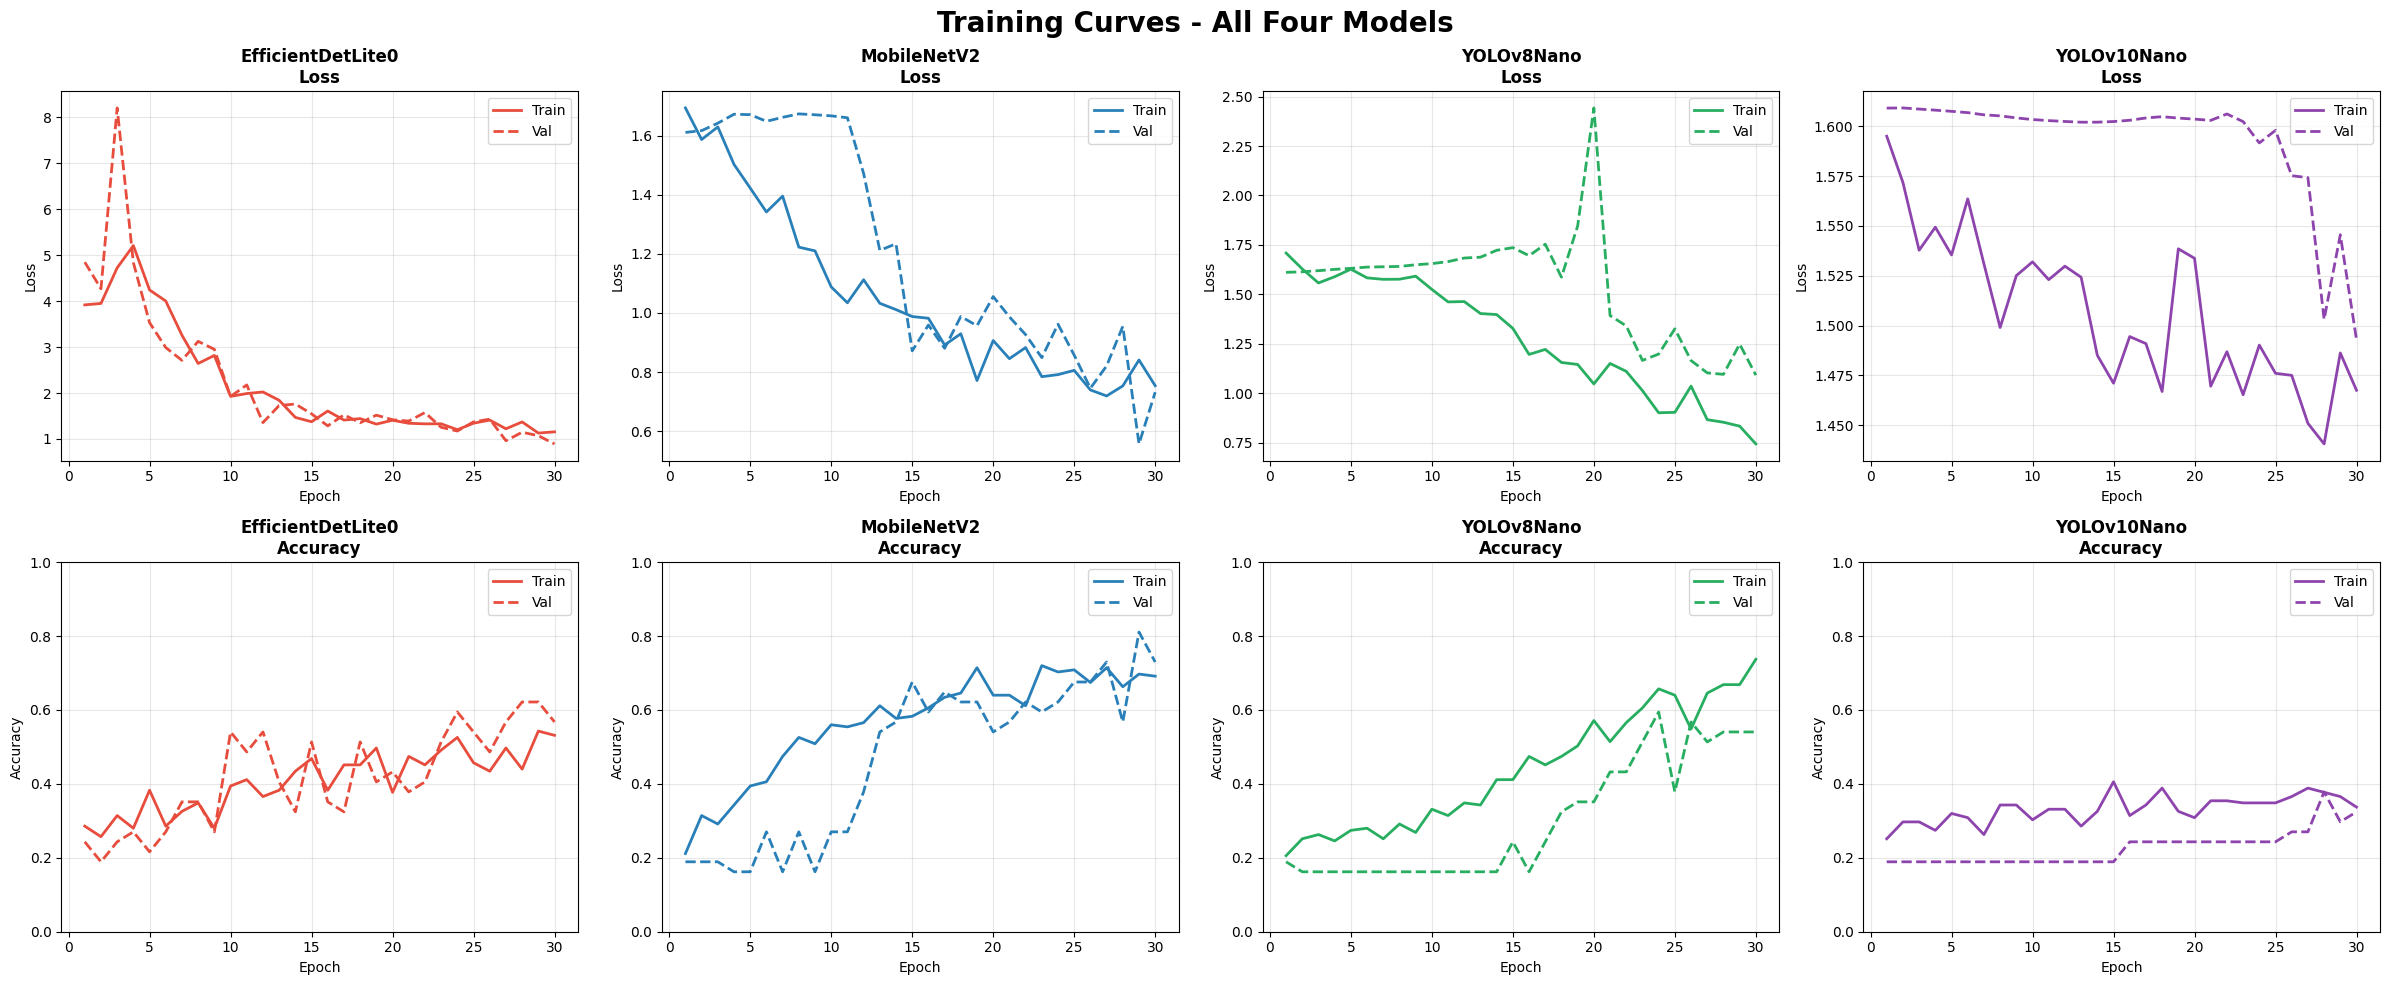

Saved: ..\outputs\figures\lab07_training_curves.png


In [11]:

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

required_histories = ["history_a", "history_b", "history_c", "history_d"]
missing_histories = [k for k in required_histories if k not in globals()]
if missing_histories:
    raise RuntimeError(f"Run Cell 10 first. Missing variables: {missing_histories}")

model_curve_entries = [
    (MODEL_A_NAME, history_a, "#E74C3C"),
    (MODEL_B_NAME, history_b, "#2980B9"),
    (MODEL_C_NAME, history_c, "#27AE60"),
    (MODEL_D_NAME, history_d, "#8E44AD"),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for col, (name, history, color) in enumerate(model_curve_entries):
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0, col].plot(epochs, history["train_loss"], color=color, linewidth=2, label="Train")
    axes[0, col].plot(epochs, history["val_loss"], color=color, linestyle="--", linewidth=2, label="Val")
    axes[0, col].set_title(f"{name}\nLoss", fontweight="bold")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(alpha=0.3)
    axes[0, col].legend()

    axes[1, col].plot(epochs, history["train_acc"], color=color, linewidth=2, label="Train")
    axes[1, col].plot(epochs, history["val_acc"], color=color, linestyle="--", linewidth=2, label="Val")
    axes[1, col].set_title(f"{name}\nAccuracy", fontweight="bold")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Accuracy")
    axes[1, col].set_ylim(0, 1)
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend()

plt.suptitle("Training Curves - All Four Models", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_training_curves.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_training_curves.png")

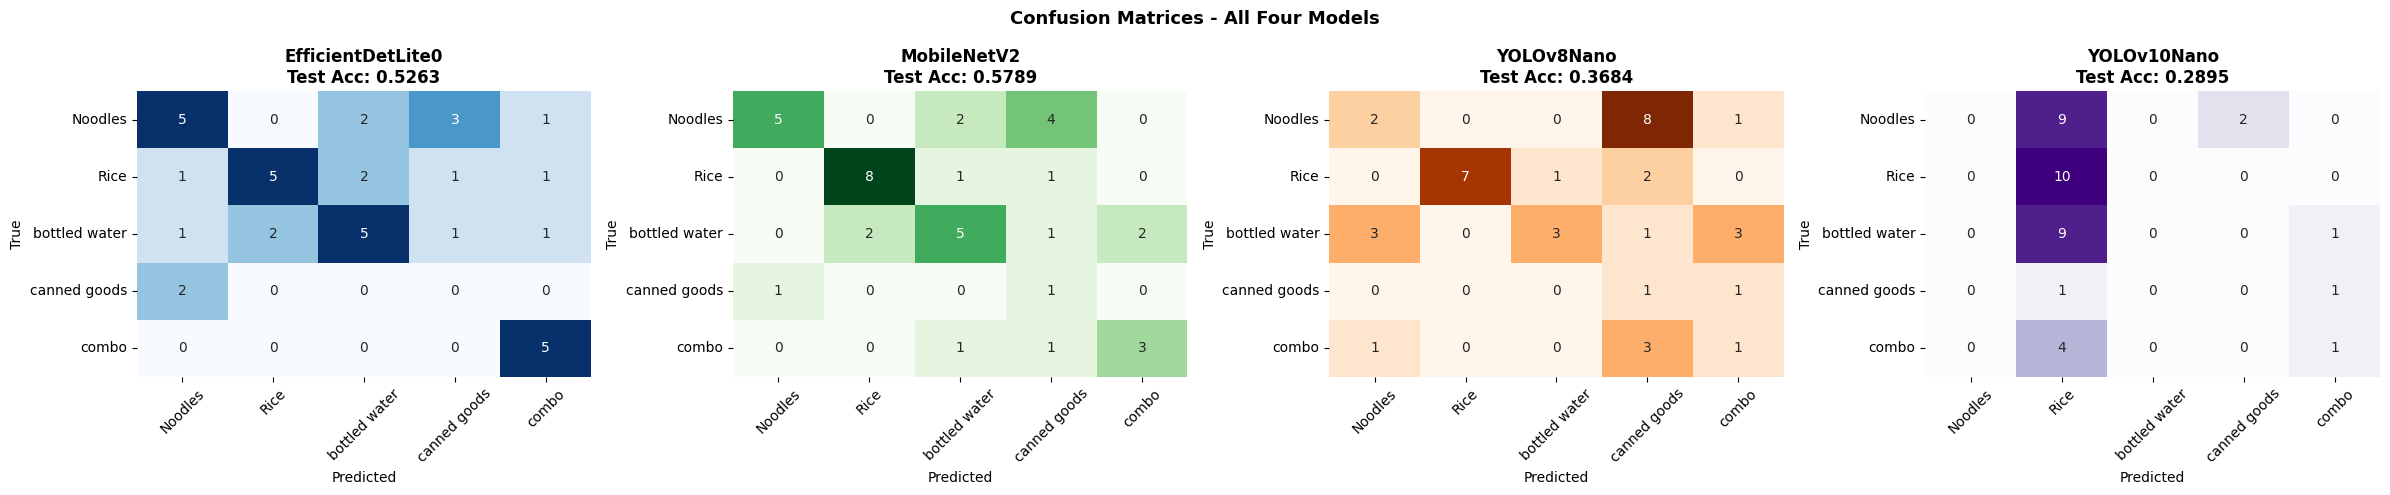

Saved: ..\outputs\figures\lab07_confusion_matrices.png


In [12]:

from sklearn.metrics import confusion_matrix, accuracy_score


def get_predictions_dl(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.max(1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def get_predictions_ml(model, X_test):
    return model.predict(X_test)


MODEL_A_NAME = globals().get("MODEL_A_NAME", "EfficientDetLite0")
MODEL_B_NAME = globals().get("MODEL_B_NAME", "MobileNetV2")
MODEL_C_NAME = globals().get("MODEL_C_NAME", "YOLOv8Nano")
MODEL_D_NAME = globals().get("MODEL_D_NAME", "YOLOv10Nano")

model_entries = [
    ("A", MODEL_A_NAME, model_a, "Blues"),
    ("B", MODEL_B_NAME, model_b, "Greens"),
    ("C", MODEL_C_NAME, model_c, "Oranges"),
    ("D", MODEL_D_NAME, model_d, "Purples"),
]

all_predictions = {}
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (key, name, mdl, cmap) in zip(axes, model_entries):
    y_true, y_pred = get_predictions_dl(mdl, test_loader)
    all_predictions[key] = (y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        cmap=cmap,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{name}\nTest Acc: {acc:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Confusion Matrices - All Four Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_confusion_matrices.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_confusion_matrices.png")

(y_true_a, y_pred_a) = all_predictions["A"]
(y_true_b, y_pred_b) = all_predictions["B"]
(y_true_c, y_pred_c) = all_predictions["C"]
(y_true_d, y_pred_d) = all_predictions["D"]

In [13]:

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


def compute_metrics(y_true, y_pred, model_name, params=None, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{'=' * 60}")
    print(f"Model: {model_name}")
    print(f"Test Accuracy      : {acc:.4f}")
    print(f"Precision (macro) : {prec:.4f}")
    print(f"Recall (macro)    : {rec:.4f}")
    print(f"F1-Score (macro)  : {f1:.4f}")
    if params is not None:
        print(f"Parameters (#)    : {int(params):,}")
    else:
        print("Parameters (#)    : N/A")
    if train_time is not None:
        print(f"Training Time (s) : {float(train_time):.1f}")
    else:
        print("Training Time (s) : N/A")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    return {
        "Model": model_name,
        "Test Accuracy": float(acc),
        "Precision (macro)": float(prec),
        "Recall (macro)": float(rec),
        "F1-Score (macro)": float(f1),
        "Training Time (s)": float(train_time) if train_time is not None else np.nan,
        "Parameters (#)": int(params) if params is not None else np.nan,
    }


required_vars = [
    "y_true_a", "y_pred_a",
    "y_true_b", "y_pred_b",
    "y_true_c", "y_pred_c",
    "y_true_d", "y_pred_d",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Run Cell 12 first. Missing variables: {missing}")

MODEL_A_NAME = globals().get("MODEL_A_NAME", "EfficientDetLite0")
MODEL_B_NAME = globals().get("MODEL_B_NAME", "MobileNetV2")
MODEL_C_NAME = globals().get("MODEL_C_NAME", "YOLOv8Nano")
MODEL_D_NAME = globals().get("MODEL_D_NAME", "YOLOv10Nano")

metric_rows = [
    compute_metrics(y_true_a, y_pred_a, MODEL_A_NAME, params=globals().get("params_a"), train_time=globals().get("time_a")),
    compute_metrics(y_true_b, y_pred_b, MODEL_B_NAME, params=globals().get("params_b"), train_time=globals().get("time_b")),
    compute_metrics(y_true_c, y_pred_c, MODEL_C_NAME, params=globals().get("params_c"), train_time=globals().get("time_c")),
    compute_metrics(y_true_d, y_pred_d, MODEL_D_NAME, params=globals().get("params_d"), train_time=globals().get("time_d")),
]


Model: EfficientDetLite0
Test Accuracy      : 0.5263
Precision (macro) : 0.4901
Recall (macro)    : 0.4909
F1-Score (macro)  : 0.4768
Parameters (#)    : 3,377,413
Training Time (s) : 554.6

Classification Report:
               precision    recall  f1-score   support

      Noodles       0.56      0.45      0.50        11
         Rice       0.71      0.50      0.59        10
bottled water       0.56      0.50      0.53        10
 canned goods       0.00      0.00      0.00         2
        combo       0.62      1.00      0.77         5

     accuracy                           0.53        38
    macro avg       0.49      0.49      0.48        38
 weighted avg       0.58      0.53      0.54        38


Model: MobileNetV2
Test Accuracy      : 0.5789
Precision (macro) : 0.5828
Recall (macro)    : 0.5709
F1-Score (macro)  : 0.5429
Parameters (#)    : 2,230,277
Training Time (s) : 513.9

Classification Report:
               precision    recall  f1-score   support

      Noodles       0.

## Part G) Generate Comparison Summary

In [14]:

TABLES_DIR = Path("../outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

if "metric_rows" not in globals():
    raise RuntimeError("Run Cell 13 first to compute model metrics.")


def best_val_accuracy(history):
    val_acc = history.get("val_acc", [])
    return float(max(val_acc)) if len(val_acc) > 0 else np.nan


def overfitting_flag(history, threshold=0.05):
    train_acc = history.get("train_acc", [])
    val_acc = history.get("val_acc", [])
    if len(train_acc) == 0 or len(val_acc) == 0:
        return "N/A"
    return "Y" if (train_acc[-1] - val_acc[-1]) > threshold else "N"


MODEL_A_NAME = globals().get("MODEL_A_NAME", "EfficientDetLite0")
MODEL_B_NAME = globals().get("MODEL_B_NAME", "MobileNetV2")
MODEL_C_NAME = globals().get("MODEL_C_NAME", "YOLOv8Nano")
MODEL_D_NAME = globals().get("MODEL_D_NAME", "YOLOv10Nano")

model_histories = {
    "A": history_a,
    "B": history_b,
    "C": history_c,
    "D": history_d,
}
model_names = {
    "A": MODEL_A_NAME,
    "B": MODEL_B_NAME,
    "C": MODEL_C_NAME,
    "D": MODEL_D_NAME,
}
model_times = {
    "A": globals().get("time_a"),
    "B": globals().get("time_b"),
    "C": globals().get("time_c"),
    "D": globals().get("time_d"),
}
model_params = {
    "A": globals().get("params_a"),
    "B": globals().get("params_b"),
    "C": globals().get("params_c"),
    "D": globals().get("params_d"),
}

summary_rows = []
for idx, key in enumerate(["A", "B", "C", "D"]):
    base = metric_rows[idx]
    train_time = model_times[key]
    params = model_params[key]
    best_val = best_val_accuracy(model_histories[key])

    summary_rows.append(
        {
            "Model": model_names[key],
            "Test Accuracy": round(base["Test Accuracy"], 4),
            "Precision (macro)": round(base["Precision (macro)"], 4),
            "Recall (macro)": round(base["Recall (macro)"], 4),
            "F1-Score (macro)": round(base["F1-Score (macro)"], 4),
            "Training Time (s)": round(float(train_time), 1) if train_time is not None else "N/A",
            "Parameters (#)": f"{int(params):,}" if params is not None else "N/A",
            "Best Val Accuracy": round(best_val, 4) if not np.isnan(best_val) else "N/A",
            "Overfitting (Y/N)": overfitting_flag(model_histories[key]),
        }
    )

df_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "Model",
        "Test Accuracy",
        "Precision (macro)",
        "Recall (macro)",
        "F1-Score (macro)",
        "Training Time (s)",
        "Parameters (#)",
        "Best Val Accuracy",
        "Overfitting (Y/N)",
    ],
)

print(df_summary.to_string(index=False))
df_summary.to_csv(TABLES_DIR / "lab07_model_comparison.csv", index=False)
print("\nSaved:", TABLES_DIR / "lab07_model_comparison.csv")

rows = summary_rows

            Model  Test Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Training Time (s) Parameters (#)  Best Val Accuracy Overfitting (Y/N)
EfficientDetLite0         0.5263             0.4901          0.4909            0.4768              554.6      3,377,413             0.6216                 N
      MobileNetV2         0.5789             0.5828          0.5709            0.5429              513.9      2,230,277             0.8108                 N
       YOLOv8Nano         0.3684             0.4633          0.3764            0.3574              417.0      3,011,807             0.5946                 Y
      YOLOv10Nano         0.2895             0.1273          0.2400            0.1430              440.4      2,708,974             0.3784                 N

Saved: ..\outputs\tables\lab07_model_comparison.csv


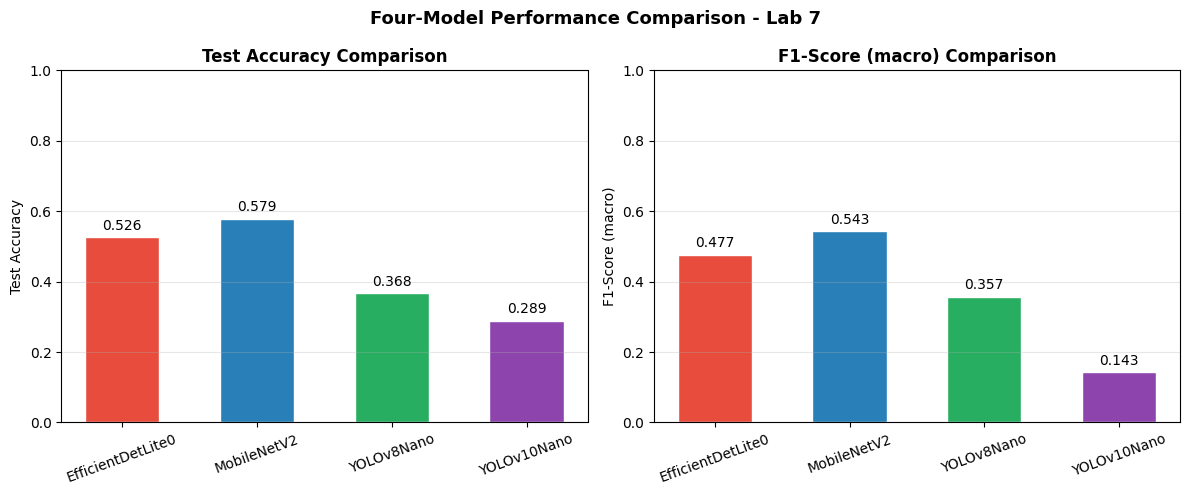

Saved: ..\outputs\figures\lab07_accuracy_comparison.png


In [15]:

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if "rows" not in globals():
    raise RuntimeError("Run Cell 14 first to build summary rows.")

model_names = [r["Model"] for r in rows]
acc_values = [float(r["Test Accuracy"]) for r in rows]
f1_values = [float(r["F1-Score (macro)"]) for r in rows]
colors = ["#E74C3C", "#2980B9", "#27AE60", "#8E44AD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, title, ylabel in [
    (axes[0], acc_values, "Test Accuracy Comparison", "Test Accuracy"),
    (axes[1], f1_values, "F1-Score (macro) Comparison", "F1-Score (macro)"),
]:
    bars = ax.bar(model_names, values, color=colors, edgecolor="white", width=0.55)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(bars, fmt="%.3f", padding=3)

plt.suptitle("Four-Model Performance Comparison - Lab 7", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_accuracy_comparison.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_accuracy_comparison.png")